# Customer Churn Prediction for a Subscription Business
End-to-end implementation of the proposal: supervised binary classification to
flag customers likely to cancel within 30 days, with SMOTE for class imbalance,
F2-optimised thresholds, SHAP explanations, batch scoring, and a business-impact
& sensitivity analysis.

**Pipeline:** `data_prep` → `eda` → `train` → `explain` → `score` → `business_impact`.

## 0. Setup

In [1]:
import sys, json
sys.path.append('src')
import pandas as pd
from IPython.display import Image, display
pd.set_option('display.max_columns', 30)

## 1. Data preparation
Real Kaggle **Telco Customer Churn** (7,043 rows) adapted to a SaaS scenario:
columns reinterpreted, five synthetic engagement features added (conditioned on
the churn label, with overlap + label noise), churners downsampled to a realistic
**5%** churn rate. See `reports/feature_notes.md` for feature realism.

In [2]:
import data_prep; data_prep.main()
df = pd.read_csv('data/processed/saas_churn.csv')
print('churn rate:', round(df['churn_30d'].mean(), 4))
df.head()

rows=5446  features=18  churn_rate=4.994%
churners=272  saved -> data\processed\saas_churn.csv
churn rate: 0.0499


,customer_id,months_subscribed,monthly_fee,total_spend,plan_type,payment_method,paperless_billing,is_senior,has_partner,has_dependents,addon_services,logins_30d,features_used,open_tickets_30d,days_since_last_interaction,usage_change_pct,snapshot_date,churn_30d
0,9661-JALZV,58,24.70,1519.0,biennial,Credit card (automatic),1,0,0,0,0,10,4,1,3,4.8,2024-01-01,0
1,4114-QMKVN,56,68.75,3815.4,annual,Bank transfer (automatic),0,0,1,1,3,15,5,1,9,15.0,2024-01-01,0
2,2969-QWUBZ,2,51.40,96.8,monthly,Electronic check,0,0,0,0,3,20,2,0,19,-4.8,2024-01-01,0
3,1986-PHGZF,18,58.40,964.9,monthly,Credit card (automatic),1,1,0,0,2,9,3,0,8,13.9,2024-01-01,0
4,9554-DFKIC,30,54.45,1588.7,monthly,Bank transfer (automatic),1,0,1,1,1,19,8,0,4,15.5,2024-01-01,0


## 2. Exploratory analysis
Engagement features separate churners; monthly plans and short tenure churn most.

shape=(5446, 18)  churn_rate=4.99%

missing values: none

churn by plan_type:
 plan_type
annual      0.015813
biennial    0.005435
monthly     0.098294
Name: churn_30d, dtype: float64



figures saved -> outputs\eda


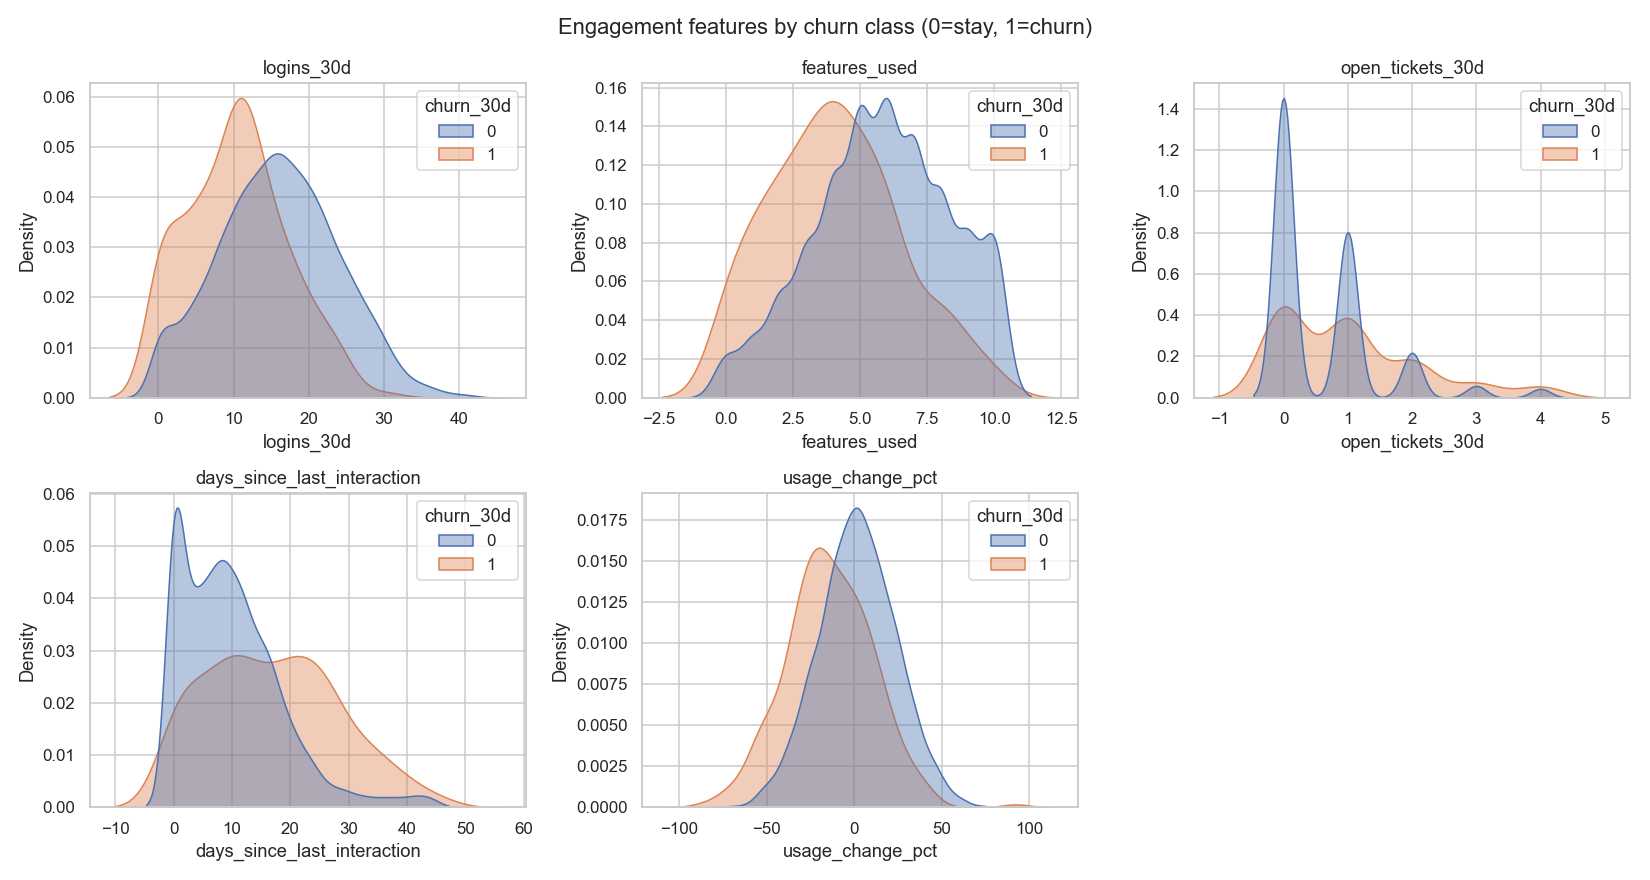

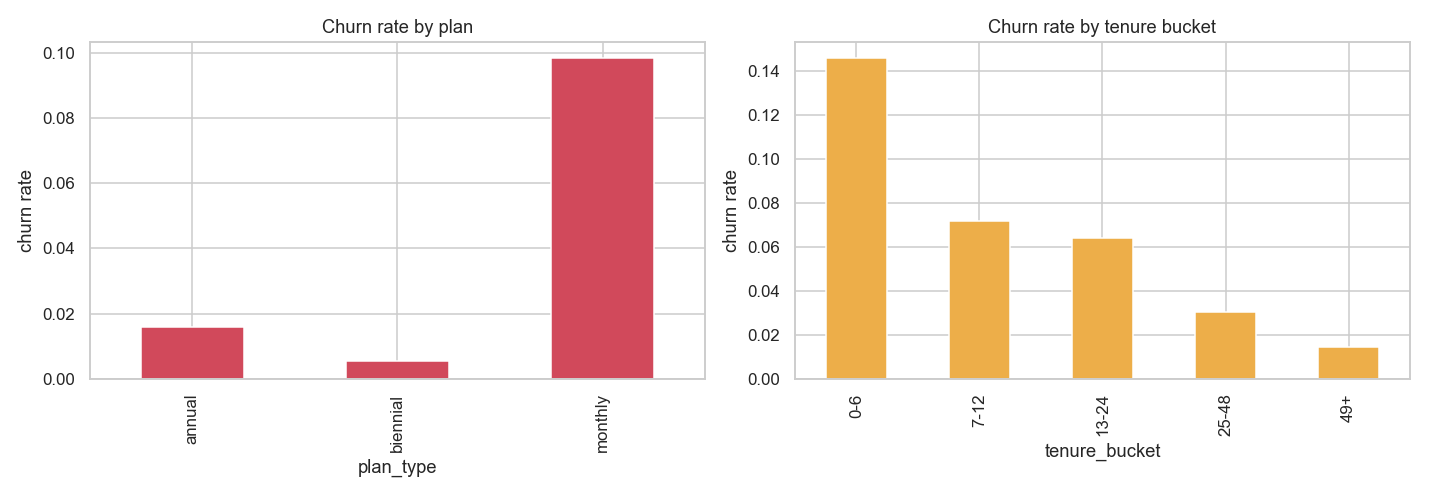

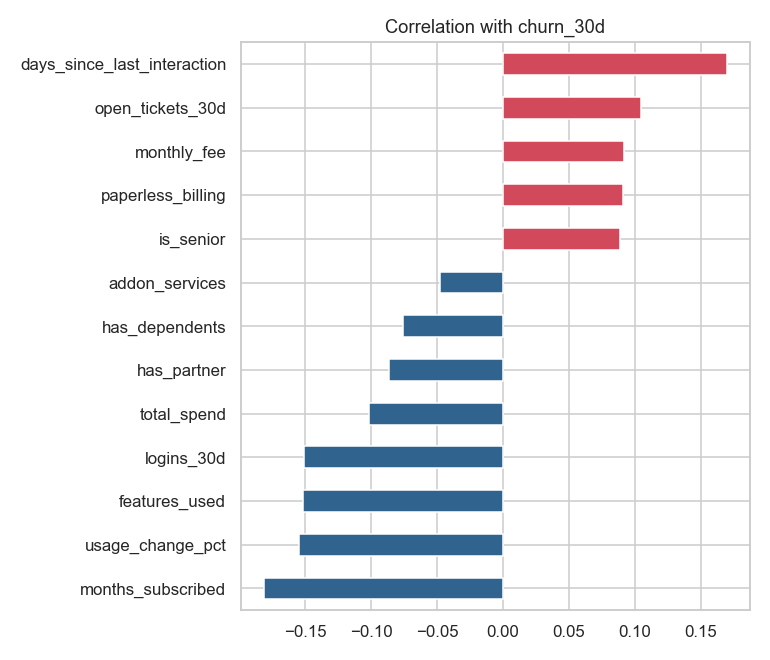

In [3]:
import eda; eda.main()
for f in ['engagement_by_churn','churn_by_segment','target_correlation']:
    display(Image(f'outputs/eda/{f}.png'))

## 3. Modeling & evaluation
Chronological train/val/test split (no leakage), SMOTE on train only. Three models;
the decision threshold is tuned on validation to maximise **F2** (recall-weighted).
Target from the proposal: **AUC > 0.80, churner recall > 0.75**.

split rows  train=3812 val=817 test=817
churn rate  train=4.93% val=5.75% test=4.53%


train after SMOTE: [3624 3624]
{'model': 'logreg', 'threshold': 0.523, 'f2': 0.559, 'auc': 0.943, 'recall': 0.865, 'precision': 0.232}


{'model': 'random_forest', 'threshold': 0.331, 'f2': 0.576, 'auc': 0.933, 'recall': 0.838, 'precision': 0.256}


{'model': 'xgboost', 'threshold': 0.275, 'f2': 0.531, 'auc': 0.932, 'recall': 0.784, 'precision': 0.232}

best model = random_forest



saved -> outputs/model.joblib, outputs/metrics.json, figures/


,model,threshold,f2,auc,recall,precision
0,logreg,0.523,0.559,0.943,0.865,0.232
1,random_forest,0.331,0.576,0.933,0.838,0.256
2,xgboost,0.275,0.531,0.932,0.784,0.232


best model: random_forest


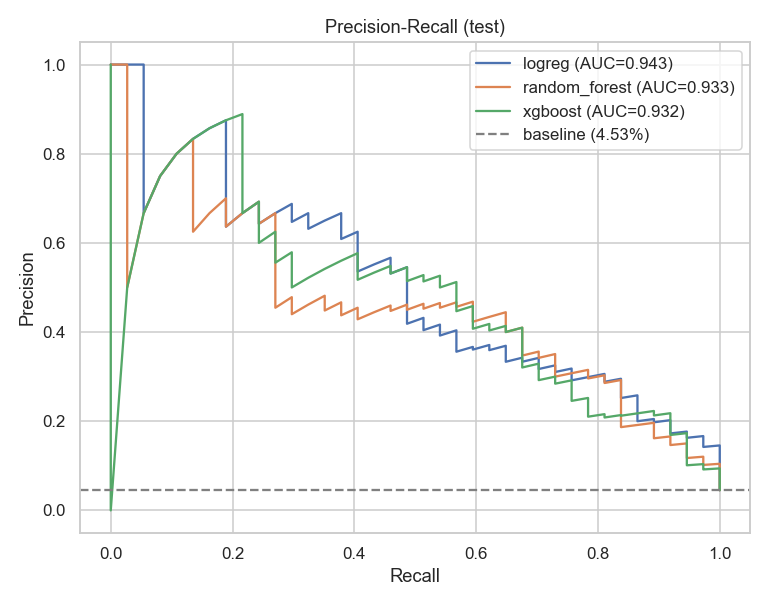

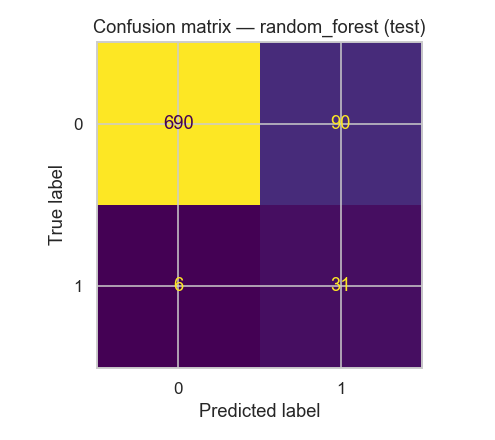

In [4]:
import train; train.main()
metrics = json.loads(open('outputs/metrics.json').read())
display(pd.DataFrame(metrics['results']))
print('best model:', metrics['best'])
for f in ['pr_curves','confusion_matrix']:
    display(Image(f'outputs/figures/{f}.png'))

## 4. Interpretability (SHAP)
Global drivers and an individual explanation, so the retention team knows *why*
a customer is flagged.

top drivers: ['plan_type_monthly', 'months_subscribed', 'usage_change_pct', 'logins_30d', 'days_since_last_interaction', 'monthly_fee', 'features_used', 'payment_method_Electronic check']
figures saved -> outputs\figures


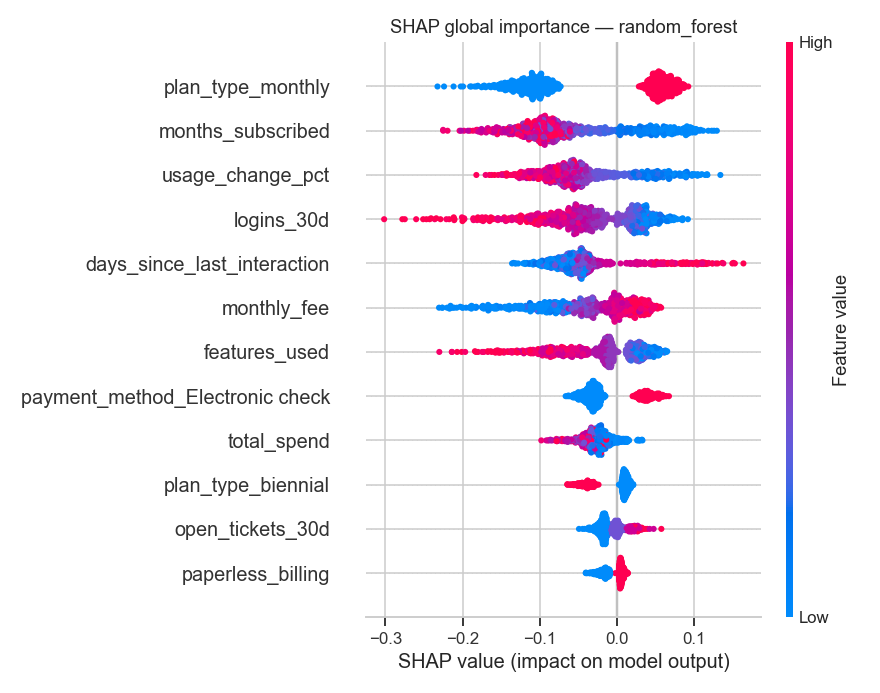

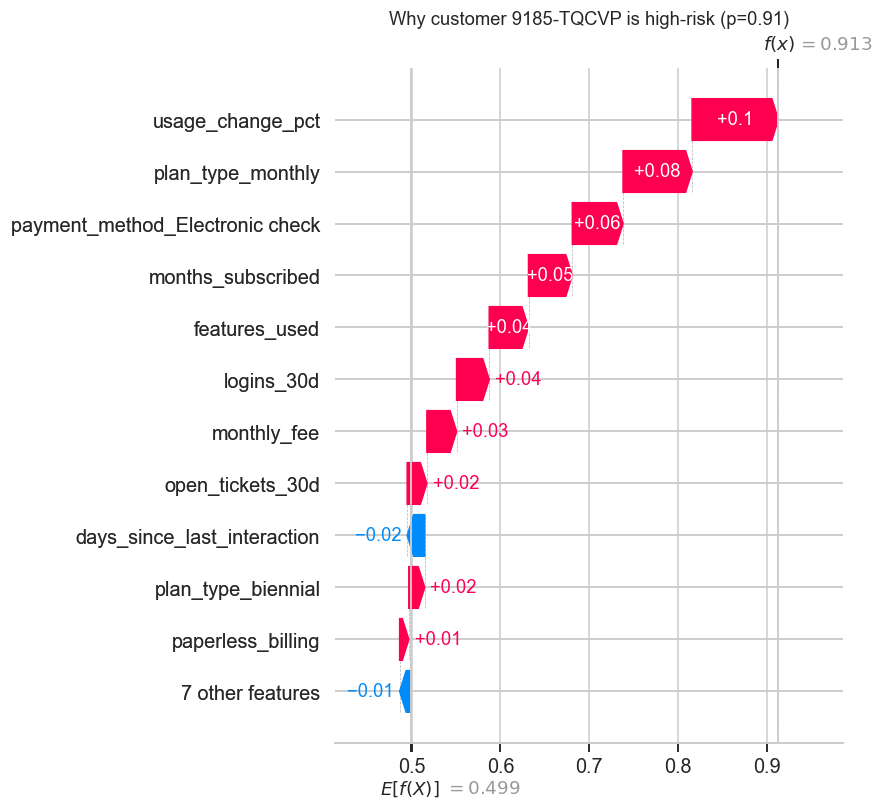

In [5]:
import explain; explain.main()
for f in ['shap_summary','shap_customer']:
    display(Image(f'outputs/figures/{f}.png'))

## 5. Batch scoring output
The production-style table the Customer Success team consumes: probability, risk
tier, and a suggested action per customer.

In [6]:
import score; score.main()
pd.read_csv('outputs/churn_scores.csv').head(10)

scored 817 customers
risk_tier
low       557
medium    139
high      121

high-risk sample:
customer_id snapshot_date plan_type  months_subscribed  monthly_fee  churn_probability risk_tier                                           suggested_action
 9185-TQCVP    2024-11-17   monthly                 14        85.15             0.9130      high Personal outreach from a success manager + retention offer
 8035-PWSEV    2024-11-18   monthly                  6        89.25             0.9096      high Personal outreach from a success manager + retention offer
 6894-LFHLY    2024-11-30   monthly                  1        75.75             0.8830      high Personal outreach from a success manager + retention offer
 6683-VLCTZ    2024-12-10   monthly                 20        98.55             0.8324      high Personal outreach from a success manager + retention offer
 8111-RKSPX    2024-12-09   monthly                  4        72.20             0.8317      high Personal outreach from a succes

,customer_id,snapshot_date,plan_type,months_subscribed,monthly_fee,churn_probability,risk_tier,suggested_action
0,9185-TQCVP,2024-11-17,monthly,14,85.15,0.9130,high,Personal outreach from a success manager + ret...
1,8035-PWSEV,2024-11-18,monthly,6,89.25,0.9096,high,Personal outreach from a success manager + ret...
2,6894-LFHLY,2024-11-30,monthly,1,75.75,0.8830,high,Personal outreach from a success manager + ret...
3,6683-VLCTZ,2024-12-10,monthly,20,98.55,0.8324,high,Personal outreach from a success manager + ret...
4,8111-RKSPX,2024-12-09,monthly,4,72.20,0.8317,high,Personal outreach from a success manager + ret...
5,2962-XPMCQ,2024-11-06,monthly,2,45.15,0.8158,high,Personal outreach from a success manager + ret...
6,5442-BHQNG,2024-12-07,monthly,2,70.35,0.8080,high,Personal outreach from a success manager + ret...
7,5429-LWCMV,2024-11-25,monthly,12,89.15,0.8021,high,Personal outreach from a success manager + ret...
8,9221-OTIVJ,2024-11-17,monthly,14,104.85,0.7971,high,Personal outreach from a success manager + ret...
9,7912-SYRQT,2024-11-28,monthly,7,75.10,0.7614,high,Personal outreach from a success manager + ret...


## 6. Business impact & sensitivity
The 20% churn-reduction target is **derived**, not assumed:
`reduction = recall × intervention_success_rate`. We vary the success rate, and
separately show how false-positive outreach cost (driven by precision) erodes ROI —
directly addressing the reviewer's feedback.

using random_forest: recall=0.838 precision=0.256

    success_rate | churn_reduction% |         saved/mo |       flagged/mo |      net_Y1(EUR) |     net_Y2+(EUR) |          ROI_Y1%
            0.15 |             12.6 |             62.8 |           1637.0 |             4168 |            24168 |               16
             0.2 |             16.8 |             83.8 |           1637.0 |            14224 |            34224 |               55
            0.24 |             20.1 |            100.6 |           1637.0 |            22269 |            42269 |               86
             0.3 |             25.1 |            125.7 |           1637.0 |            34336 |            54336 |              132
             0.4 |             33.5 |            167.6 |           1637.0 |            54448 |            74448 |              209

~20% reduction is reached at success_rate=0.24 (recall 0.838 x 0.24 = 20%)

precision sensitivity (central success rate, adding outreach cost):
   outreach/contac


saved -> outputs/business_impact.json, figures/sensitivity.png


,intervention_success_rate,churn_reduction_pct,customers_saved_per_month,flagged_per_month,net_benefit_year1,net_benefit_year2plus,roi_year1_pct
0,0.15,12.6,62.8,1637.0,4168,24168,16
1,0.20,16.8,83.8,1637.0,14224,34224,55
2,0.24,20.1,100.6,1637.0,22269,42269,86
3,0.30,25.1,125.7,1637.0,34336,54336,132
4,0.40,33.5,167.6,1637.0,54448,74448,209


,outreach_unit,intervention_success_rate,churn_reduction_pct,customers_saved_per_month,flagged_per_month,net_benefit_year1,net_benefit_year2plus,roi_year1_pct
0,0,0.24,20.1,100.6,1637.0,22269,42269,86
1,5,0.24,20.1,100.6,1637.0,-75934,-55934,-61
2,10,0.24,20.1,100.6,1637.0,-174137,-154137,-78
3,20,0.24,20.1,100.6,1637.0,-370544,-350544,-88


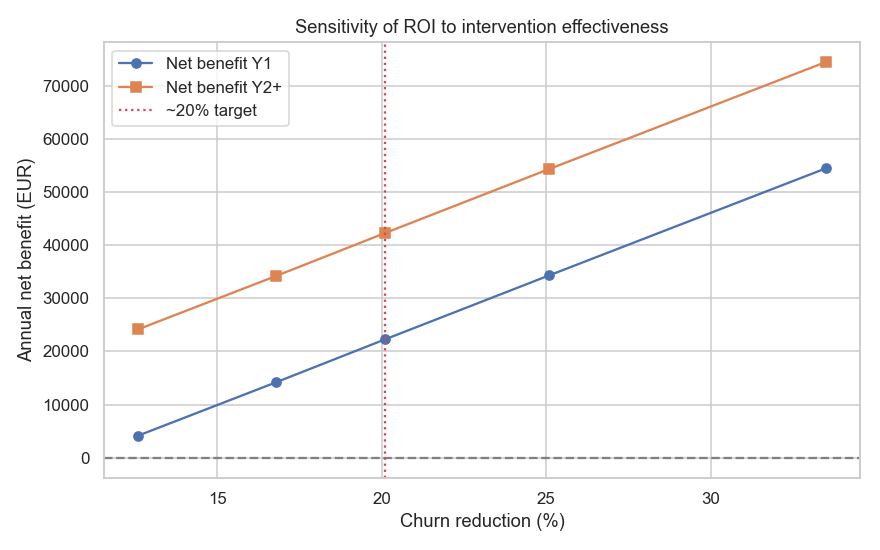

In [7]:
import business_impact; business_impact.main()
bi = json.loads(open('outputs/business_impact.json').read())
display(pd.DataFrame(bi['scenarios']))
display(pd.DataFrame(bi['outreach_sensitivity']))
display(Image('outputs/figures/sensitivity.png'))

## 7. Conclusions
- The model meets the proposal's technical targets (AUC ≈ 0.93, churner recall ≈ 0.84).
- At a 5% base rate, a recall-first threshold flags many false positives (low
  precision) — the retention **discount** model still yields the proposal's
  ~€22k Y1 / €42k Y2+, but adding per-contact outreach cost turns ROI negative,
  so **precision / top-N targeting is the key lever** before scaling outreach.
- Synthetic features are literature-grounded but simplified; production telemetry
  (events, support, billing, logged outcomes) would replace them and let the
  intervention-success rate be measured rather than assumed.